# Ensemble Learning — Stacking, Bagging, Boosting

This notebook walks through every ensemble family from the notes, in the same order:

1. Baseline — a single Decision Tree (something to beat)
2. Stacking — base models' predictions feed a meta-model
3. Bagging — Random Forest
4. Boosting — AdaBoost
5. Boosting — Gradient Boosting
6. Boosting — XGBoost
7. Final comparison of all models

Dataset: **Iris** (`sns.load_dataset('iris')`) — 3-class classification, same dataset used throughout.


## 0. Imports & Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    StackingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42

# a running scoreboard we fill in as we go
scoreboard = {}

## 1. Load Data & Train/Test Split

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = df.drop('species', axis=1)
le = LabelEncoder()
y_encoded = le.fit_transform(df['species'])   # models need numeric labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)
print(f"Train size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")

Train size: 120   Test size: 30


## 2. Baseline — a Single Decision Tree

Ensembles only earn their keep if they beat a single model. This is what we're trying to improve on.


In [4]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
acc = accuracy_score(y_test, dt_model.predict(X_test))
scoreboard['Decision Tree (baseline)'] = acc
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9333


## 3. Stacking — Base Models' Predictions Become New Features

Base learners: Decision Tree, SVM, Logistic Regression.
Meta-model: Logistic Regression, trained on the base learners' out-of-fold predictions.


In [5]:
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('svc', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(max_iter=1000)),
]
meta_learner = LogisticRegression(max_iter=1000)

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)
stacking_clf.fit(X_train, y_train)

acc = accuracy_score(y_test, stacking_clf.predict(X_test))
scoreboard['Stacking'] = acc
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9667


## 4. Bagging — Random Forest

Random Forest = Bagging + Decision Trees, with a random subset of features considered at each split.
Trees are trained **in parallel** on bootstrap samples of the data; predictions are combined by voting.


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=None,     # let trees grow fully
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

acc = accuracy_score(y_test, rf_model.predict(X_test))
scoreboard['Bagging (Random Forest)'] = acc
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9000


## 5. Boosting — AdaBoost

Boosting trains models **sequentially** — each new model focuses on the mistakes of the previous
one. AdaBoost does this by re-weighting misclassified samples so the next learner pays more
attention to them.


In [7]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
ada_model.fit(X_train, y_train)

acc = accuracy_score(y_test, ada_model.predict(X_test))
scoreboard['Boosting (AdaBoost)'] = acc
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9333


## 6. Boosting — Gradient Boosting

Instead of re-weighting samples, each new model fits the **residual errors** of the ensemble so far.


In [8]:
gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE
)
gb_model.fit(X_train, y_train)

acc = accuracy_score(y_test, gb_model.predict(X_test))
scoreboard['Boosting (Gradient Boosting)'] = acc
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9667


## 7. Boosting — XGBoost

An optimized, regularized implementation of gradient boosting — usually faster and stronger
than plain Gradient Boosting.


In [9]:
xgb_model = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)

acc = accuracy_score(y_test, xgb_model.predict(X_test))
scoreboard['Boosting (XGBoost)'] = acc
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9333


## 8. Final Comparison

In [10]:
scores_df = pd.DataFrame(
    sorted(scoreboard.items(), key=lambda kv: kv[1], reverse=True),
    columns=['Model', 'Test Accuracy']
)
scores_df

,Model,Test Accuracy
0,Stacking,0.966667
1,Boosting (Gradient Boosting),0.966667
2,Decision Tree (baseline),0.933333
3,Boosting (AdaBoost),0.933333
4,Boosting (XGBoost),0.933333
5,Bagging (Random Forest),0.900000


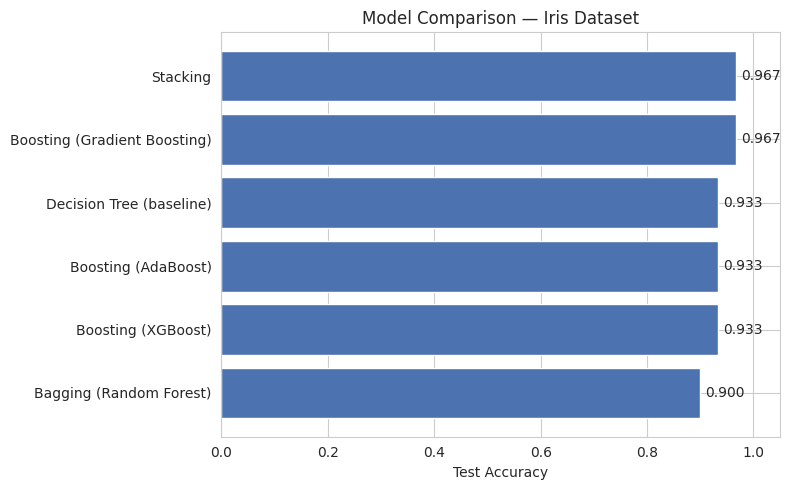

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(scores_df['Model'], scores_df['Test Accuracy'], color='#4C72B0')
plt.xlabel('Test Accuracy')
plt.title('Model Comparison — Iris Dataset')
plt.xlim(0, 1.05)
for i, v in enumerate(scores_df['Test Accuracy']):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Takeaways

- **Stacking** combines *different kinds* of models via a meta-model that learns how to weigh them.
- **Bagging** (Random Forest) trains the *same* model type in parallel on bootstrap samples —
  mainly reduces **variance**.
- **Boosting** (AdaBoost / Gradient Boosting / XGBoost) trains models *sequentially*, each
  correcting the last — mainly reduces **bias**.
- On a small, clean dataset like Iris, most of these will score similarly high — the real
  differences show up on noisier, larger, real-world datasets.
